In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Feature-Selection-:

In [19]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset_own.csv')

In [20]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [21]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [22]:
# drop month,day and year-:
df.drop(["month","day","year"],axis=1,inplace=True)

In [23]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [24]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [25]:
# Encoding-:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)

In [27]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [28]:
# Independent and dependent features-:
X = df.drop('FWI',axis=1)

In [29]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [30]:
y = df["FWI"]

In [31]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [32]:
# Train Test split-:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [33]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [35]:
# Feature Selection based on correlation-:
# Negatively correlated features should NOT be removed 
# But; Highly positively correlated features CAN be removed
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


In [44]:
X_train.corr().columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'Classes', 'Region'],
      dtype='object')

In [53]:
X_train.corr().iloc[1][0]

np.float64(-0.6560952065209624)

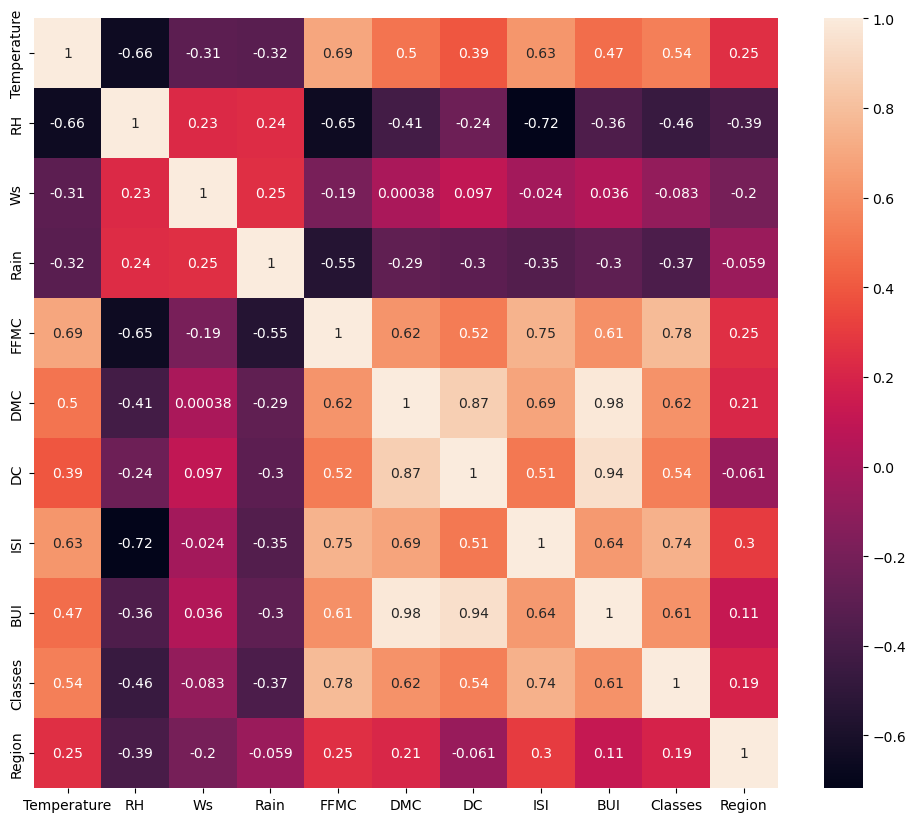

In [41]:
# Check for Multicollinearity-:
# Multicollinearity means more than two independent variables in a dataset are highly correlated with each other.

# This makes it difficult for a model to determine the individual effect of each variable.

# So; its better to remove REMOVE either of any one feature via FEATURE-SELECTION.

plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [ ]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    # It loops only through the lower triangle of the correlation matrix
    # It avoids checking:
    # Same column with itself (diagonal = 1)
    # Duplicate comparisons (A-B and B-A)
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            # we use "abs()" to take only magintude and remove sign from CORRELATION value
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
# It checks correlation between features only
# It does NOT use entire matrix
# It checks only one half (to avoid repetition)

In [72]:
abs(-23)

23

In [56]:
# threshold is generally set by Domain expertise
corr_features = correlation(X_train,0.85)

In [57]:
corr_features

{'BUI', 'DC'}

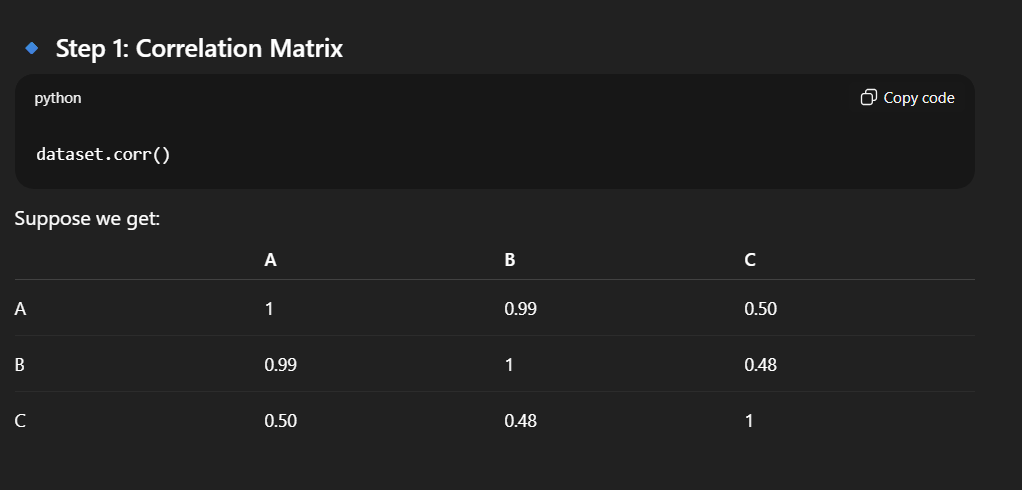
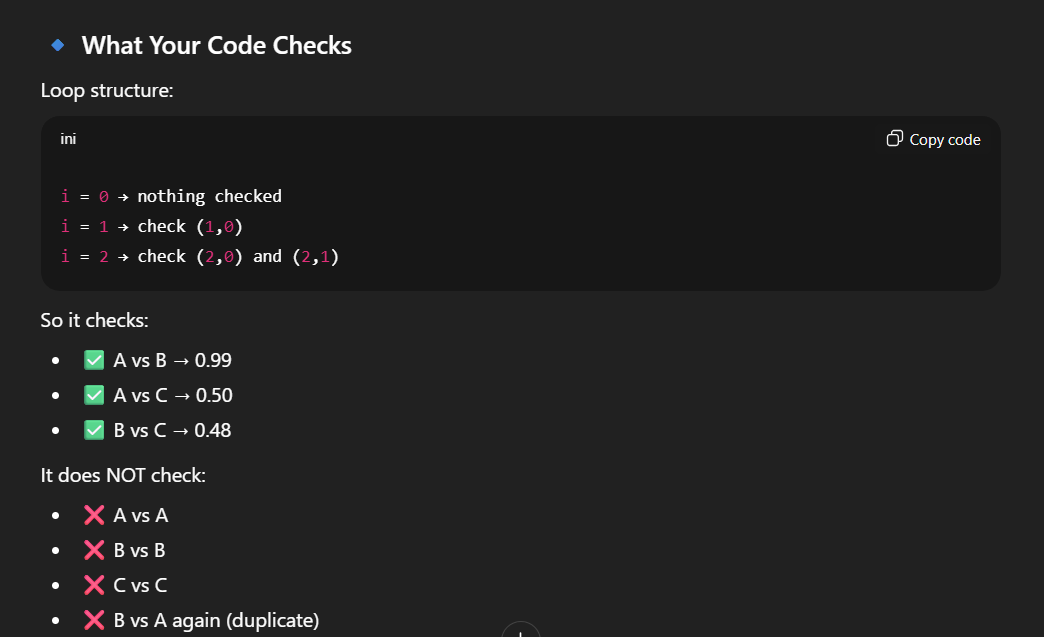
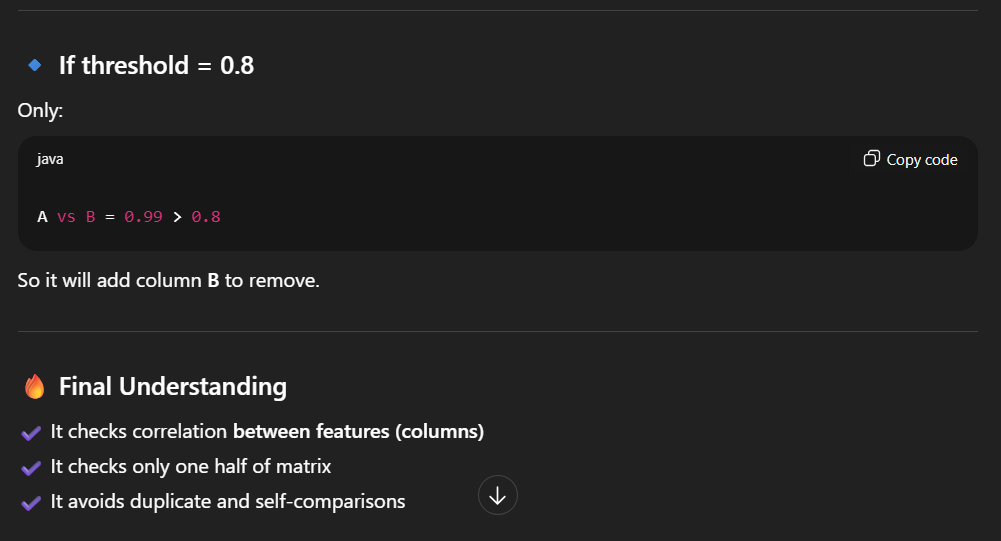

In [58]:
# Now; After performing multi-collinearity-: BUI & DC can be removed as their correlation is more than 0.85-:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

In [62]:
# Feature Scaling or Standardization-:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# StandardScaler() → Mean 0, Std 1 (no fixed range) => STANDARDIZATION
# MinMaxScaler() → Scales to fixed range (like 0 to 1) => NORMALIZATION
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
X_test_scaled

array([[-3.01758418e-01,  1.15223531e-01, -2.19053977e-01,
        -3.84060174e-01,  6.33218240e-01, -4.25075679e-02,
         2.03772218e-01,  9.05538514e-01, -9.89070710e-01],
       [ 2.39325642e-01, -5.52632606e-01, -9.78441098e-01,
        -3.84060174e-01,  7.37980727e-01, -3.83352062e-01,
         3.65823283e-01,  9.05538514e-01, -9.89070710e-01],
       [-1.11338451e+00, -2.85490151e-01,  9.20026704e-01,
         6.45241658e-01, -9.73139891e-01, -9.14435344e-01,
        -8.37984627e-01, -1.10431526e+00,  1.01105006e+00],
       [ 5.09867672e-01, -2.85490151e-01, -9.78441098e-01,
        -2.90487280e-01,  1.30358303e-01,  3.14190159e-01,
        -6.29633258e-01, -1.10431526e+00,  1.01105006e+00],
       [-5.72300448e-01,  1.82009145e-01, -5.98747538e-01,
        -3.84060174e-01,  5.42424085e-01,  1.00171523e-01,
        -7.40296073e-02,  9.05538514e-01,  1.01105006e+00],
       [ 1.86257782e+00,  1.15223531e-01, -2.49721534e+00,
         1.77377189e-01, -2.67739147e-01, -2.406729

# Box Plots to understand Effect of Standard Scaler

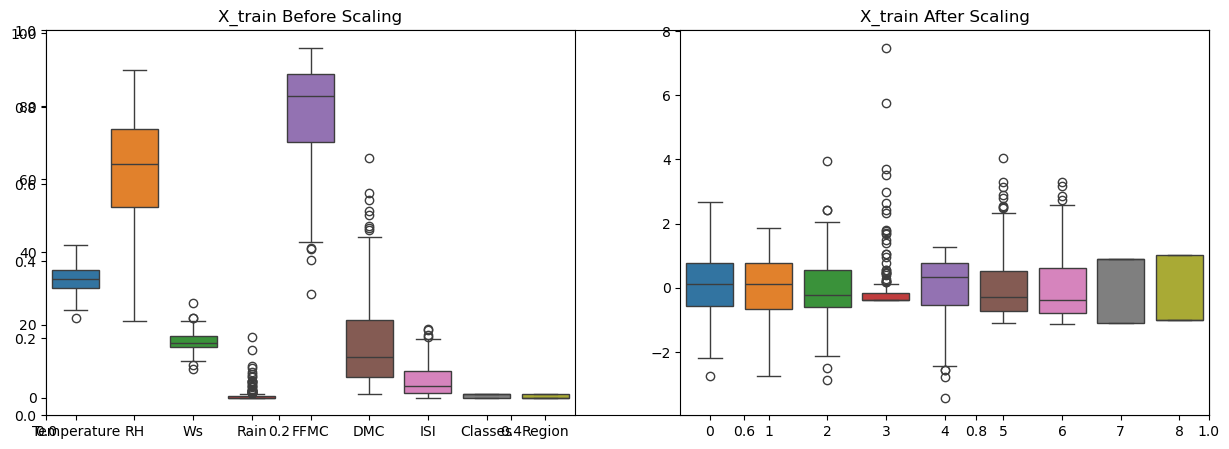

In [69]:
# It is a good step after doing STANDARDIZATION -: to look for OUTLIERS via BOXPLOT for that standardized DATASET-:
# Creates a new figure (canvas) with width = 15 inches and height = 5 inches.
plt.subplots(figsize=(15,5))
# Divides the figure into 1 row and 2 columns,
# and selects the 1st plot area (left side) to draw the graph.
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train Before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')
plt.show()

In [70]:
# 🔹 Why We Do Standardization (StandardScaler)

# 1️⃣ To make all features on the same scale (so big values don’t dominate small ones).
# 2️⃣ Required for distance-based models like KNN, SVM, K-Means.
# 3️⃣ Helps gradient descent converge faster (in Logistic Regression, Neural Networks, Linear Regression).
# 4️⃣ Improves model performance and stability.

# Linear Regression Model

Mean absolute error:0.5468236465249977
R2 Score:0.9847657384266952


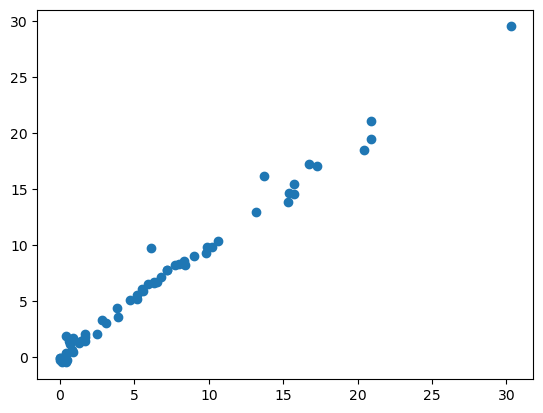

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_true=y_test,y_pred=y_pred)
print(f"Mean absolute error:{mae}")
print(f"R2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

# Lasso Regression

Mean absolute error:1.1331759949144087
R2 Score:0.9492020263112388


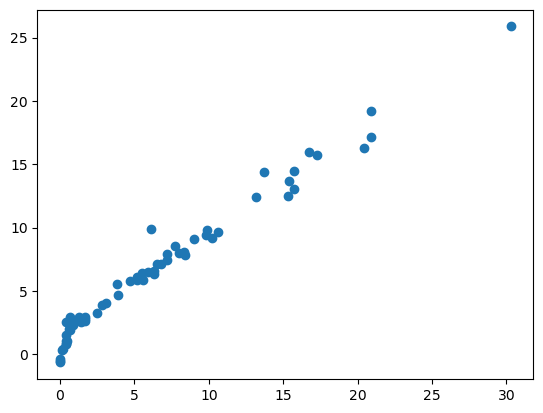

In [86]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_true=y_test,y_pred=y_pred)
print(f"Mean absolute error:{mae}")
print(f"R2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

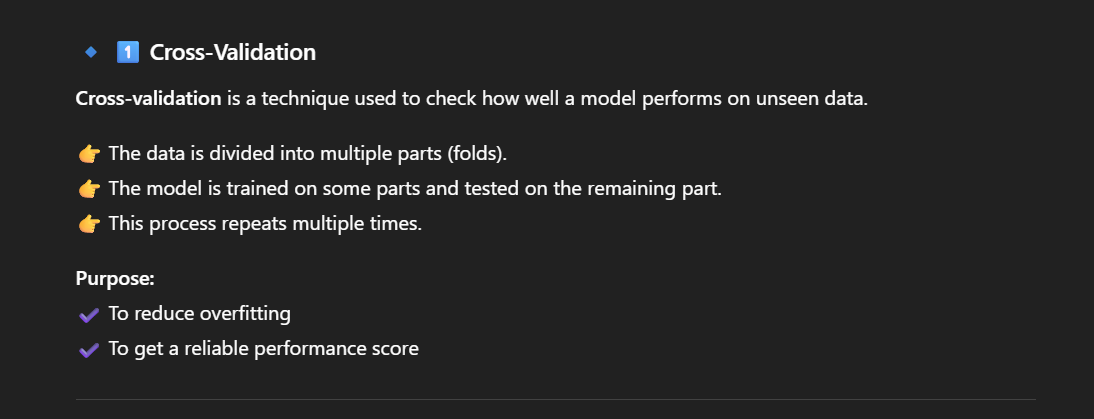
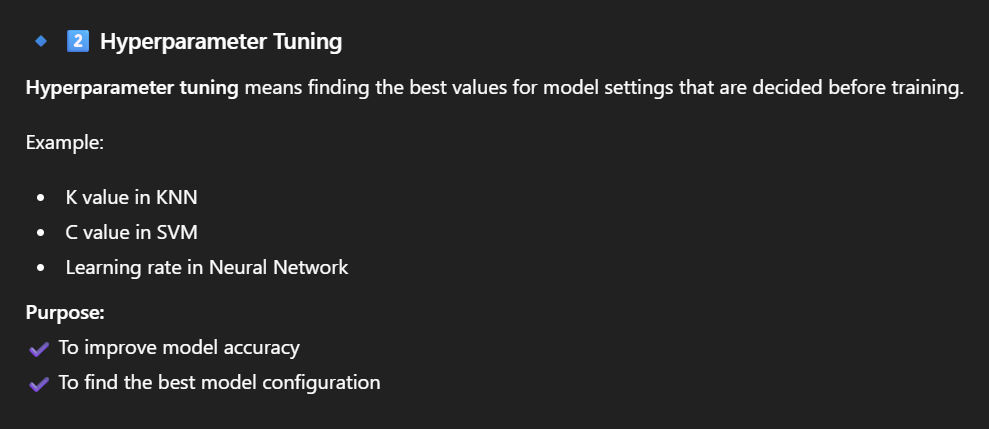
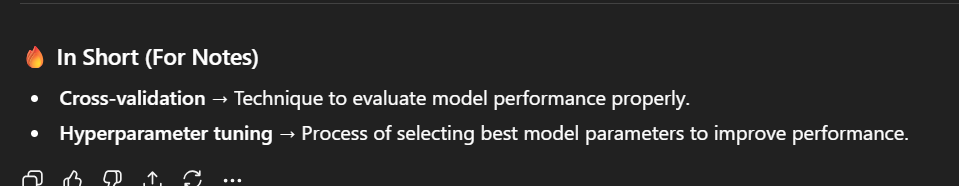

# Cross Validation Lasso

Lasso CV parameters-:
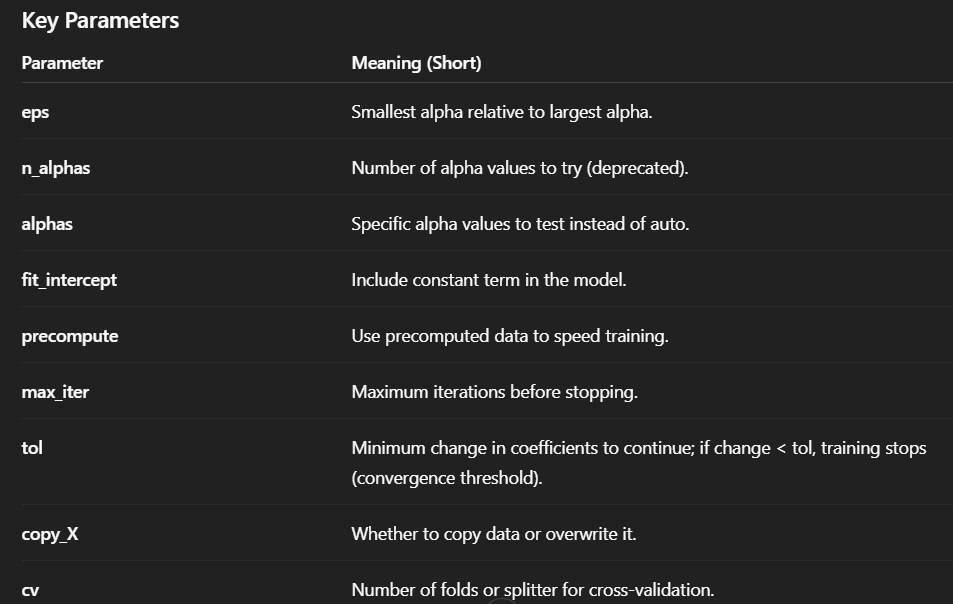
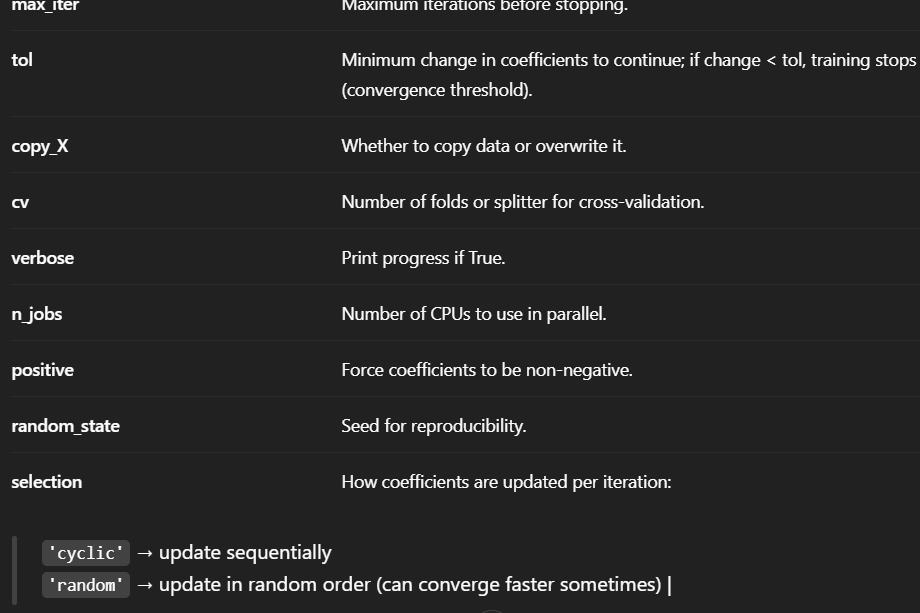
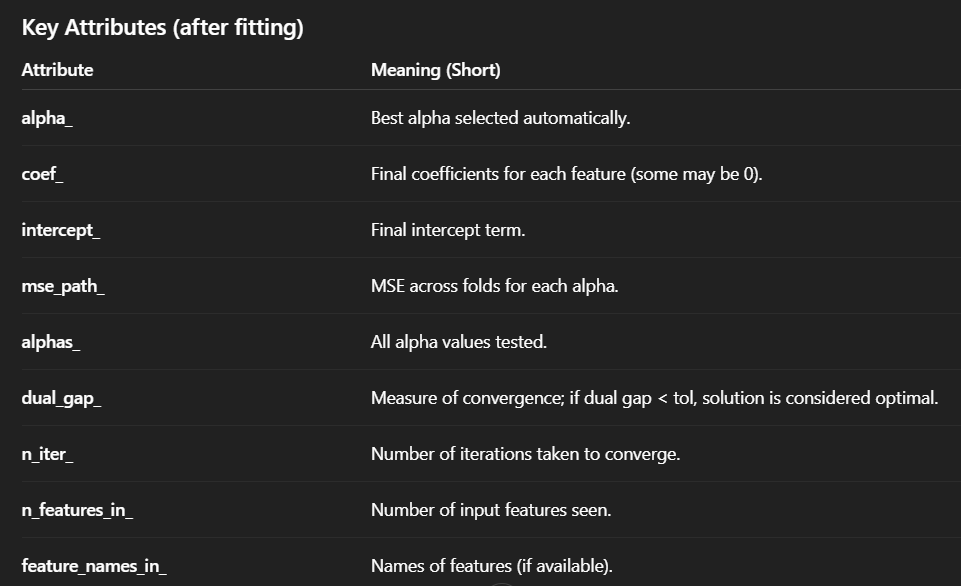
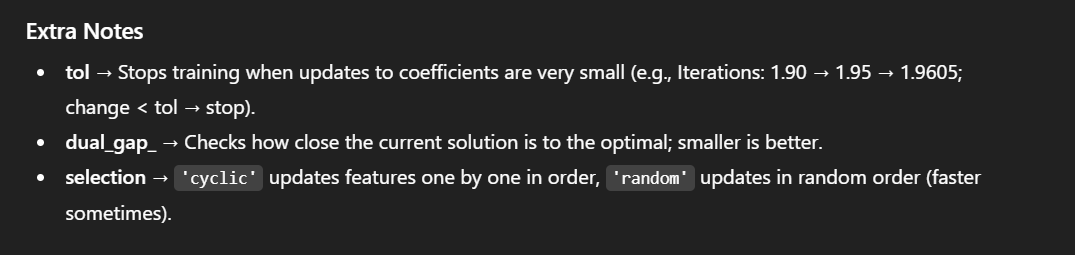
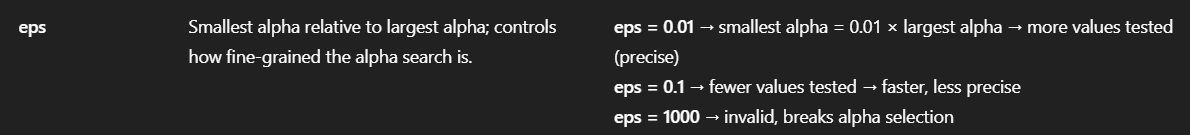

In [97]:
# LassoCV is Lasso Regression with automatic cross-validation to find the best alpha (regularization strength, not learning rate), which shrinks some coefficients to 0 for feature selection and avoids overfitting.
# In Lasso, alpha is regularization strength, not learning rate.
# Higher alpha → more penalty → more coefficients shrink to 0
# Lower alpha → less penalty → coefficients stay closer to original values
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
# We don’t standardize the output because we want predictions in real, meaningful units; only input features are scaled to help the model learn efficiently.
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

In [100]:
lassocv.predict(X_test_scaled)

array([ 8.17490595,  7.68312478, -0.25676525,  4.72643402,  6.78715772,
        1.77624325,  2.23148094,  7.64057821,  1.99176323,  3.39941035,
        0.62808928,  9.95945488,  9.36168319, 16.98503659, 18.28488762,
        1.61644108,  1.62751276, -0.6415713 ,  7.28510526,  3.10926518,
        1.95541903,  0.18069335,  6.47563129,  0.14318503, 20.99597009,
        5.11755206,  5.86208849,  9.75914403, -0.77037467,  9.91838577,
        6.72277075, -0.31776007, 10.31109643, 14.4365551 ,  1.71022677,
        0.83439752,  2.03414915,  5.97488529, -0.6263644 , -0.56200288,
        6.47253729,  2.07971408,  8.46741557, -0.8464481 , 15.40443856,
        8.32941189,  8.48782486,  1.44030355, 13.02752812,  1.20911545,
       29.08623849,  5.49737681, 17.15937199, 19.28890096, 13.71102991,
       16.05355549,  0.99056448,  9.0873725 ,  3.84455993, 14.43991192,
        5.23034139])

In [101]:
lassocv.alpha_

np.float64(0.05725391318234411)

In [103]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [109]:
lassocv.alphas_.shape
# It means the model tried 100 different alpha values.

(100,)

In [104]:
lassocv.n_iter_
# It means the algorithm needed 24 steps (iterations) to reach convergence
# kind of like-: It adjusted coefficients 24 times before stopping.

24

In [108]:
lassocv.mse_path_

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

In [110]:
lassocv.mse_path_.shape
# This one is important 👇
# 100 → alpha values tested
# 5 → number of cross-validation folds

# So for:
# Each of the 100 alphas
# It calculated error in 5 different folds

(100, 5)

In [111]:
# 100 alphas tested
# 5-fold validation used
# Error stored for each alpha in each fold
# Model converged in 24 iterations

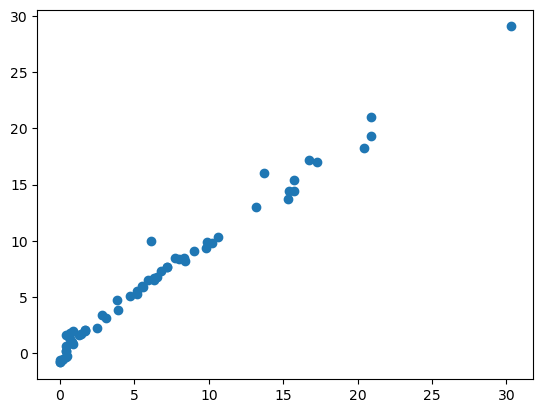

MAE: 0.6199701158263436
R2 Score: 0.9820946715928274


In [118]:
y_pred = lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
plt.show()
mae =  mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"MAE: {mae}\nR2 Score: {score}")

# Ridge Regression

Mean absolute error:0.5642305340105683
R2 Score:0.9842993364555513


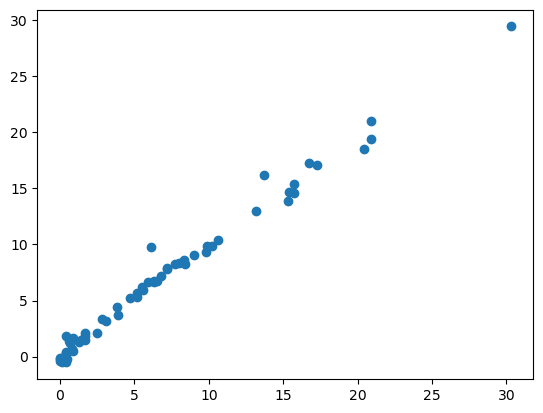

In [90]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_true=y_test,y_pred=y_pred)
print(f"Mean absolute error:{mae}")
print(f"R2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

# Ridge Regression CV

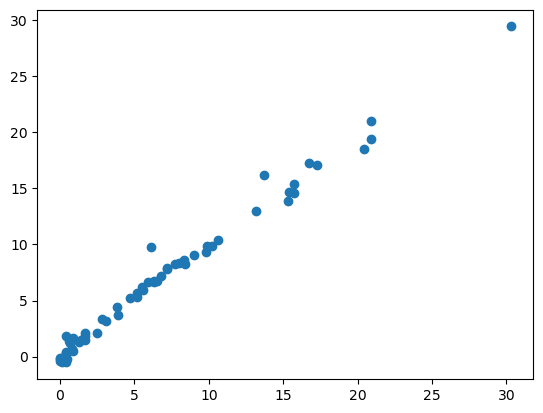

MAE: 0.5642305340105683
R2 Score: 0.9842993364555513


In [121]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred = ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
plt.show()
mae =  mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"MAE: {mae}\nR2 Score: {score}")

In [124]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [123]:
ridgecv.alpha_

np.float64(1.0)

In [127]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

# Elasticnet Regression

Mean absolute error:1.8822353634896
R2 Score:0.8753460589519703


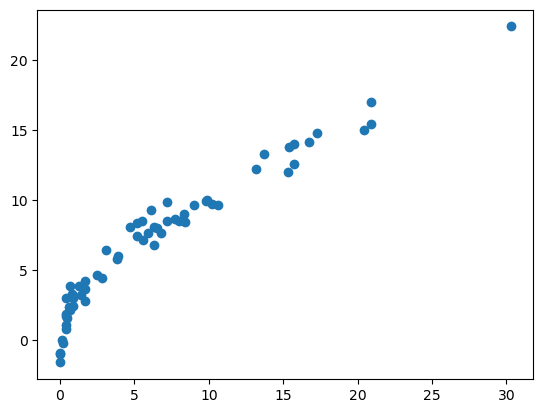

In [91]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
elastic = ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_true=y_test,y_pred=y_pred)
print(f"Mean absolute error:{mae}")
print(f"R2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

# ElasticNet CV

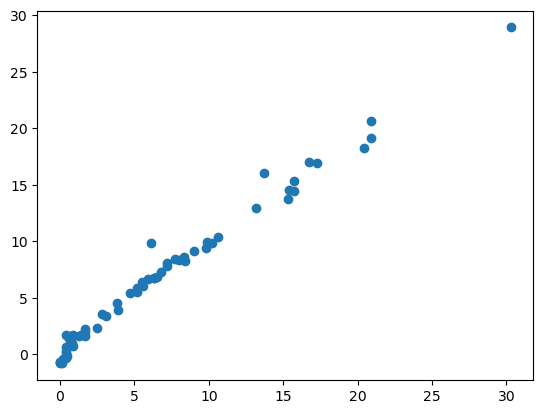

MAE: 0.6575946731430902
R2 Score: 0.9814217587854941


In [ ]:
from sklearn.linear_model import ElasticNetCV
elasticNetcv = ElasticNetCV(cv=5)
elasticNetcv.fit(X_train_scaled,y_train)
y_pred = elasticNetcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
plt.show()
mae =  mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"MAE: {mae}\nR2 Score: {score}")

In [129]:
elasticNetcv.alpha_

np.float64(0.04311146156383891)

In [130]:
elasticNetcv.alphas_

array([14.11706004, 13.16561744, 12.27829889, 11.45078264, 10.67903821,
        9.95930678,  9.28808283,  8.66209714,  8.07830078,  7.53385034,
        7.02609405,  6.55255882,  6.11093829,  5.6990815 ,  5.31498248,
        4.95677045,  4.62270071,  4.31114616,  4.02058933,  3.74961507,
        3.49690356,  3.26122397,  3.04142839,  2.83644629,  2.64527931,
        2.46699633,  2.30072904,  2.1456676 ,  2.00105679,  1.86619226,
        1.74041714,  1.62311885,  1.51372607,  1.411706  ,  1.31656174,
        1.22782989,  1.14507826,  1.06790382,  0.99593068,  0.92880828,
        0.86620971,  0.80783008,  0.75338503,  0.7026094 ,  0.65525588,
        0.61109383,  0.56990815,  0.53149825,  0.49567705,  0.46227007,
        0.43111462,  0.40205893,  0.37496151,  0.34969036,  0.3261224 ,
        0.30414284,  0.28364463,  0.26452793,  0.24669963,  0.2300729 ,
        0.21456676,  0.20010568,  0.18661923,  0.17404171,  0.16231189,
        0.15137261,  0.1411706 ,  0.13165617,  0.12278299,  0.11

# li_ratio parameter in ElasticNetCV

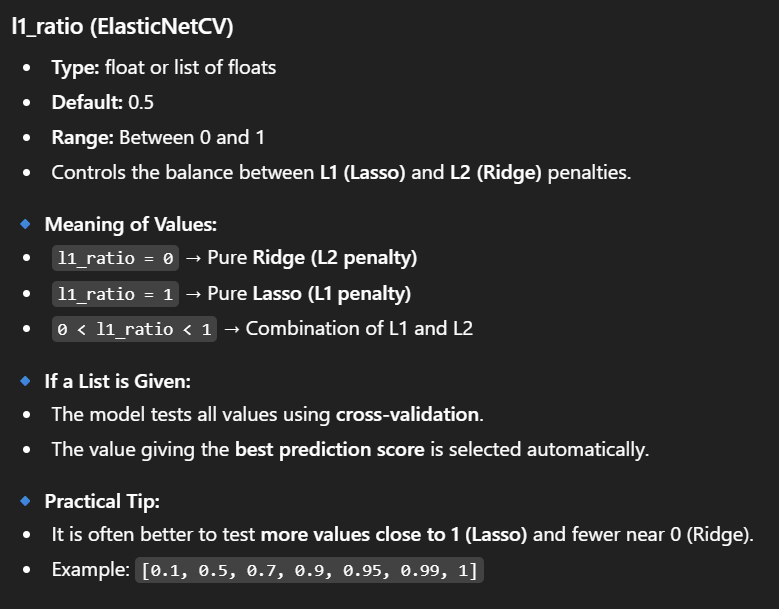


l1_ratio controls the mix of L1 and L2 penalties; 0 = Ridge, 1 = Lasso, values in between = combination, and ElasticNetCV selects the best one using cross-validation

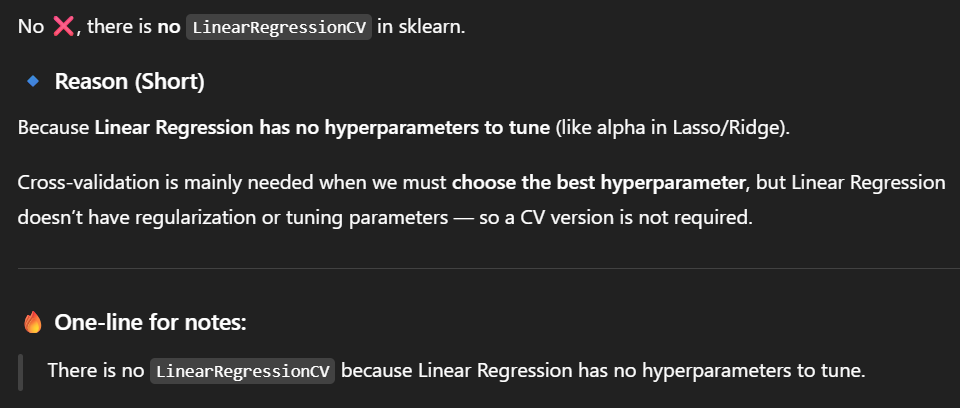
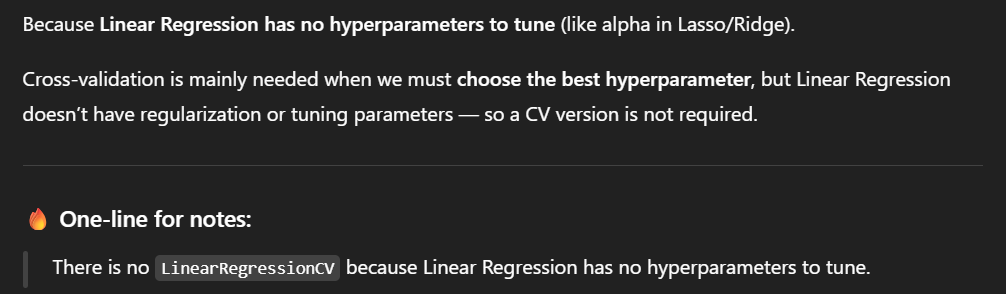

In k-fold cross-validation, each data point is used once for validation and the remaining times for training.

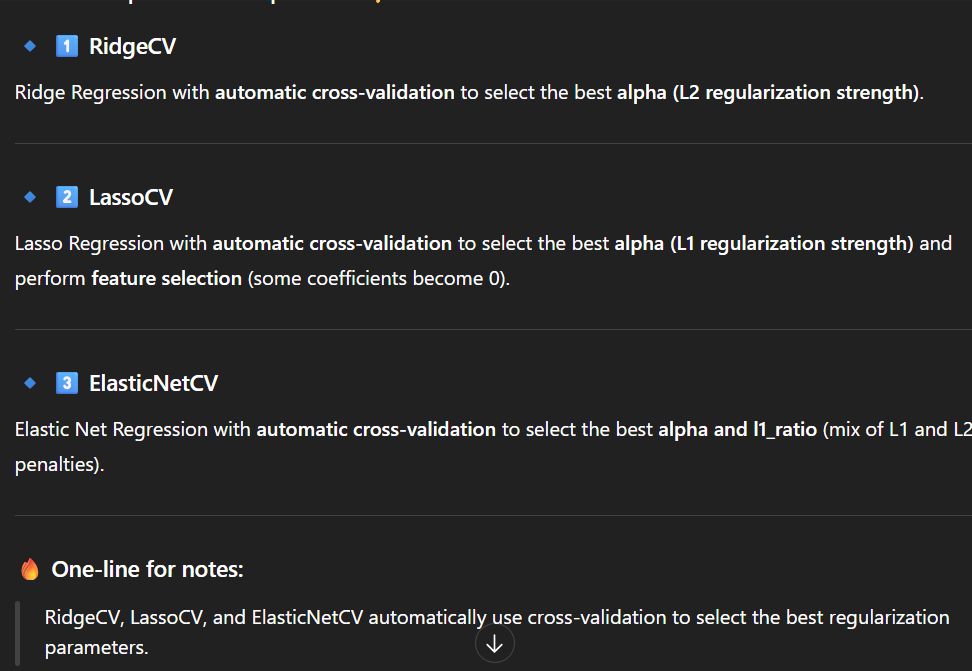